In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset

H:\ai-ml\exercise\ai-ml-exercises\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### What Are CNN Architectures?

CNN architectures are **pre-designed network structures** that have proven to work well on image tasks. Instead of guessing how many layers to use, we can learn from the best!


#### Evolution of CNNs

```
LeNet-5 (1998) → AlexNet (2012) → VGG (2014) → ResNet (2015) → EfficientNet (2019)
     ↓                ↓               ↓             ↓                ↓
Handwritten       ImageNet        Very Deep      Skip           Efficient
digits            Breakthrough    Networks       Connections    Scaling
```

| Architecture | Year | Key Contribution |
|---|---|---|
| **LeNet-5** | 1998 | Handwritten digit recognition |
| **AlexNet** | 2012 | ImageNet breakthrough |
| **VGG** | 2014 | Very deep networks |
| **ResNet** | 2015 | Skip connections |
| **EfficientNet** | 2019 | Efficient scaling |

In [4]:
print("\n" + "="*60)
print("LOADING CIFAR-10 DATA")
print("="*60)

# ✅ Same transform pipeline
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# ✅ Load CIFAR-10 from Hugging Face instead of torchvision
hf_train = load_dataset("uoft-cs/cifar10", split="train")
hf_test = load_dataset("uoft-cs/cifar10", split="test")

# ✅ Custom Dataset wrapper to make HF data behave like torchvision
class CIFAR10FromHF(Dataset):
    """Wrap a Hugging Face CIFAR-10 split into a PyTorch Dataset."""

    def __init__(self, hf_split, transform=None):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        item = self.hf_split[idx]
        img = item["img"]  # PIL Image
        label = item["label"]  # int

        if self.transform is not None:
            img = self.transform(img)

        return img, label


train_dataset = CIFAR10FromHF(hf_train, transform=transform)
test_dataset = CIFAR10FromHF(hf_test, transform=transform)

# ✅ Same data loaders
batch_size = 64
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False
)

# ✅ Same class names
classes = ['plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

# ✅ Verify — identical result
print(f"Train images: {len(train_dataset)}")
print(f"Test images:  {len(test_dataset)}")
print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")

images, labels = next(iter(train_loader))
print(f"\nBatch shape:  {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Label range:  {labels.min().item()} to {labels.max().item()}")



LOADING CIFAR-10 DATA


Train images: 50000
Test images:  10000
Train batches: 782
Test batches:  157

Batch shape:  torch.Size([64, 3, 32, 32])
Labels shape: torch.Size([64])
Label range:  0 to 9


In [8]:
print("\n" + "="*60)
print("LeNet-5 (1998)")
print("="*60)

print("""
LeNet-5 Architecture:
• Designed for MNIST (handwritten digits)
• 7 layers (2 conv, 2 pool, 3 FC)
• 60,000 parameters
• Key innovation: Convolution + Pooling

Input (32x32) → Conv1 (6 filters) → Pool1 → Conv2 (16 filters) → Pool2 → FC1 → FC2 → Output (10)
""")

class LeNet5(nn.Module):
    """LeNet-5 implementation for CIFAR-10 (adapted)"""
    def __init__(self):
        super(LeNet5, self).__init__()
        # Original LeNet takes 1 channel, we adapt to 3 for CIFAR
        self.conv1 = nn.Conv2d(3, 6, kernel_size=5, padding=2)
        self.pool1 = nn.AvgPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.pool2 = nn.AvgPool2d(2, 2)
        self.fc1 = nn.Linear(16 * 6 * 6, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.pool1(self.relu(self.conv1(x)))  # 32x32 → 16x16
        x = self.pool2(self.relu(self.conv2(x)))  # 16x16 → 6x6
        x = x.view(-1, 16 * 6 * 6)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Create model
lenet = LeNet5()
total_params = sum(p.numel() for p in lenet.parameters())
print(f"LeNet-5 Parameters: {total_params:,}")


LeNet-5 (1998)

LeNet-5 Architecture:
• Designed for MNIST (handwritten digits)
• 7 layers (2 conv, 2 pool, 3 FC)
• 60,000 parameters
• Key innovation: Convolution + Pooling

Input (32x32) → Conv1 (6 filters) → Pool1 → Conv2 (16 filters) → Pool2 → FC1 → FC2 → Output (10)

LeNet-5 Parameters: 83,126


In [9]:
print("\n" + "="*60)
print("AlexNet (2012)")
print("="*60)

print("""
AlexNet Architecture:
• Won ImageNet 2012 by huge margin
• 8 layers (5 conv, 3 FC)
• 60 million parameters!
• Key innovations: ReLU, Dropout, Data Augmentation

Input (224x224) → Conv1 (96 filters) → Pool → Conv2 (256) → Pool → Conv3 (384)
→ Conv4 (384) → Conv5 (256) → Pool → FC1 (4096) → FC2 (4096) → Output (1000)
""")

class AlexNet(nn.Module):
    """AlexNet implementation for CIFAR-10 (adapted)"""
    def __init__(self):
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            # Conv1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Conv2
            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Conv3
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            
            # Conv4
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            
            # Conv5
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, 10),
        )
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Create model
alexnet = AlexNet()
total_params = sum(p.numel() for p in alexnet.parameters())
print(f"AlexNet Parameters: {total_params:,}")


AlexNet (2012)

AlexNet Architecture:
• Won ImageNet 2012 by huge margin
• 8 layers (5 conv, 3 FC)
• 60 million parameters!
• Key innovations: ReLU, Dropout, Data Augmentation

Input (224x224) → Conv1 (96 filters) → Pool → Conv2 (256) → Pool → Conv3 (384)
→ Conv4 (384) → Conv5 (256) → Pool → FC1 (4096) → FC2 (4096) → Output (1000)

AlexNet Parameters: 35,855,178


In [10]:
print("\n" + "="*60)
print("VGG-16 (2014)")
print("="*60)

print("""
VGG-16 Architecture:
• 16 layers (13 conv, 3 FC)
• 138 million parameters!
• Key innovation: Very deep networks with small filters (3x3)
• Simple, uniform architecture

Input (224x224) → [Conv3x3 → Conv3x3 → Pool] x 5 → FC → FC → Output
""")

def make_vgg_block(in_channels, out_channels, num_convs):
    """Helper to create VGG blocks"""
    layers = []
    for i in range(num_convs):
        layers.append(nn.Conv2d(in_channels if i == 0 else out_channels, 
                                out_channels, kernel_size=3, padding=1))
        layers.append(nn.ReLU(inplace=True))
    layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
    return nn.Sequential(*layers)

class VGG16(nn.Module):
    """VGG-16 implementation for CIFAR-10 (adapted)"""
    def __init__(self):
        super(VGG16, self).__init__()
        self.features = nn.Sequential(
            # Block 1: 2 conv layers
            make_vgg_block(3, 64, 2),      # 32x32 → 16x16
            # Block 2: 2 conv layers
            make_vgg_block(64, 128, 2),    # 16x16 → 8x8
            # Block 3: 3 conv layers
            make_vgg_block(128, 256, 3),   # 8x8 → 4x4
            # Block 4: 3 conv layers
            make_vgg_block(256, 512, 3),   # 4x4 → 2x2
            # Block 5: 3 conv layers
            make_vgg_block(512, 512, 3),   # 2x2 → 1x1
        )
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(512 * 1 * 1, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 10),
        )
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Create model
vgg16 = VGG16()
total_params = sum(p.numel() for p in vgg16.parameters())
print(f"VGG-16 Parameters: {total_params:,}")


VGG-16 (2014)

VGG-16 Architecture:
• 16 layers (13 conv, 3 FC)
• 138 million parameters!
• Key innovation: Very deep networks with small filters (3x3)
• Simple, uniform architecture

Input (224x224) → [Conv3x3 → Conv3x3 → Pool] x 5 → FC → FC → Output

VGG-16 Parameters: 14,982,474


In [11]:
print("\n" + "="*60)
print("ResNet-18 (2015)")
print("="*60)

print("""
ResNet-18 Architecture:
• 18 layers with skip connections
• 11 million parameters
• Key innovation: Skip connections (residual learning)
• Solves vanishing gradient problem

Instead of learning H(x), learn F(x) + x (residual)
where F(x) = H(x) - x

This allows training of very deep networks (100+ layers)
""")

class ResidualBlock(nn.Module):
    """A residual block with skip connection"""
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 
                               kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 
                               kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
        # Skip connection (adjust dimensions if needed)
        self.skip = nn.Sequential()
        if in_channels != out_channels or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 
                         kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )
    
    def forward(self, x):
        identity = self.skip(x)
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        
        out += identity  # Skip connection
        out = self.relu(out)
        return out

class ResNet18(nn.Module):
    """ResNet-18 implementation for CIFAR-10"""
    def __init__(self):
        super(ResNet18, self).__init__()
        
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        
        # ResNet blocks
        self.layer1 = self._make_layer(64, 64, 2, stride=1)    # 32x32
        self.layer2 = self._make_layer(64, 128, 2, stride=2)   # 16x16
        self.layer3 = self._make_layer(128, 256, 2, stride=2)  # 8x8
        self.layer4 = self._make_layer(256, 512, 2, stride=2)  # 4x4
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, 10)
    
    def _make_layer(self, in_channels, out_channels, num_blocks, stride):
        layers = []
        layers.append(ResidualBlock(in_channels, out_channels, stride))
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock(out_channels, out_channels))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# Create model
resnet = ResNet18()
total_params = sum(p.numel() for p in resnet.parameters())
print(f"ResNet-18 Parameters: {total_params:,}")



ResNet-18 (2015)

ResNet-18 Architecture:
• 18 layers with skip connections
• 11 million parameters
• Key innovation: Skip connections (residual learning)
• Solves vanishing gradient problem

Instead of learning H(x), learn F(x) + x (residual)
where F(x) = H(x) - x

This allows training of very deep networks (100+ layers)

ResNet-18 Parameters: 11,178,762


In [16]:
print("\n" + "="*60)
print("COMPARING ARCHITECTURES")
print("="*60)

import time

# Function to train and evaluate a model
def train_and_evaluate(model, model_name, epochs=5):
    """Train and evaluate a model"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    train_accs = []
    test_accs = []
    
    start_time = time.time()
    
    for epoch in range(epochs):
        # Training
        model.train()
        correct_train = 0
        total_train = 0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
        
        train_acc = 100 * correct_train / total_train
        train_accs.append(train_acc)
        
        # Testing
        model.eval()
        correct_test = 0
        total_test = 0
        with torch.no_grad():
            for images, labels in test_loader:
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()
        
        test_acc = 100 * correct_test / total_test
        test_accs.append(test_acc)
        
        print(f"  {model_name} Epoch {epoch+1}/{epochs} - Train: {train_acc:.2f}%, Test: {test_acc:.2f}%")
    
    train_time = time.time() - start_time
    
    return train_accs, test_accs, train_time

# Train each model (using subset for speed)
models_to_test = [
    ('LeNet-5', LeNet5()),
    ('AlexNet', AlexNet()),
    ('VGG-16', VGG16()),
    ('ResNet-18', ResNet18())
]

results = {}
print("\nTraining all architectures...")

for name, model in models_to_test:
    print(f"\n{name}:")
    train_accs, test_accs, train_time = train_and_evaluate(model, name, epochs=3)
    results[name] = {
        'train_accs': train_accs,
        'test_accs': test_accs,
        'train_time': train_time,
        'params': sum(p.numel() for p in model.parameters())
    }



COMPARING ARCHITECTURES

Training all architectures...

LeNet-5:
  LeNet-5 Epoch 1/3 - Train: 39.15%, Test: 49.04%
  LeNet-5 Epoch 2/3 - Train: 50.01%, Test: 50.95%
  LeNet-5 Epoch 3/3 - Train: 54.09%, Test: 54.97%

AlexNet:
  AlexNet Epoch 1/3 - Train: 38.57%, Test: 48.42%
  AlexNet Epoch 2/3 - Train: 56.23%, Test: 61.13%
  AlexNet Epoch 3/3 - Train: 64.25%, Test: 67.87%

VGG-16:
  VGG-16 Epoch 1/3 - Train: 9.91%, Test: 10.00%
  VGG-16 Epoch 2/3 - Train: 9.74%, Test: 10.00%
  VGG-16 Epoch 3/3 - Train: 9.85%, Test: 10.00%

ResNet-18:
  ResNet-18 Epoch 1/3 - Train: 51.53%, Test: 63.66%
  ResNet-18 Epoch 2/3 - Train: 70.80%, Test: 71.22%
  ResNet-18 Epoch 3/3 - Train: 78.76%, Test: 77.72%



VISUALIZING ARCHITECTURE COMPARISON


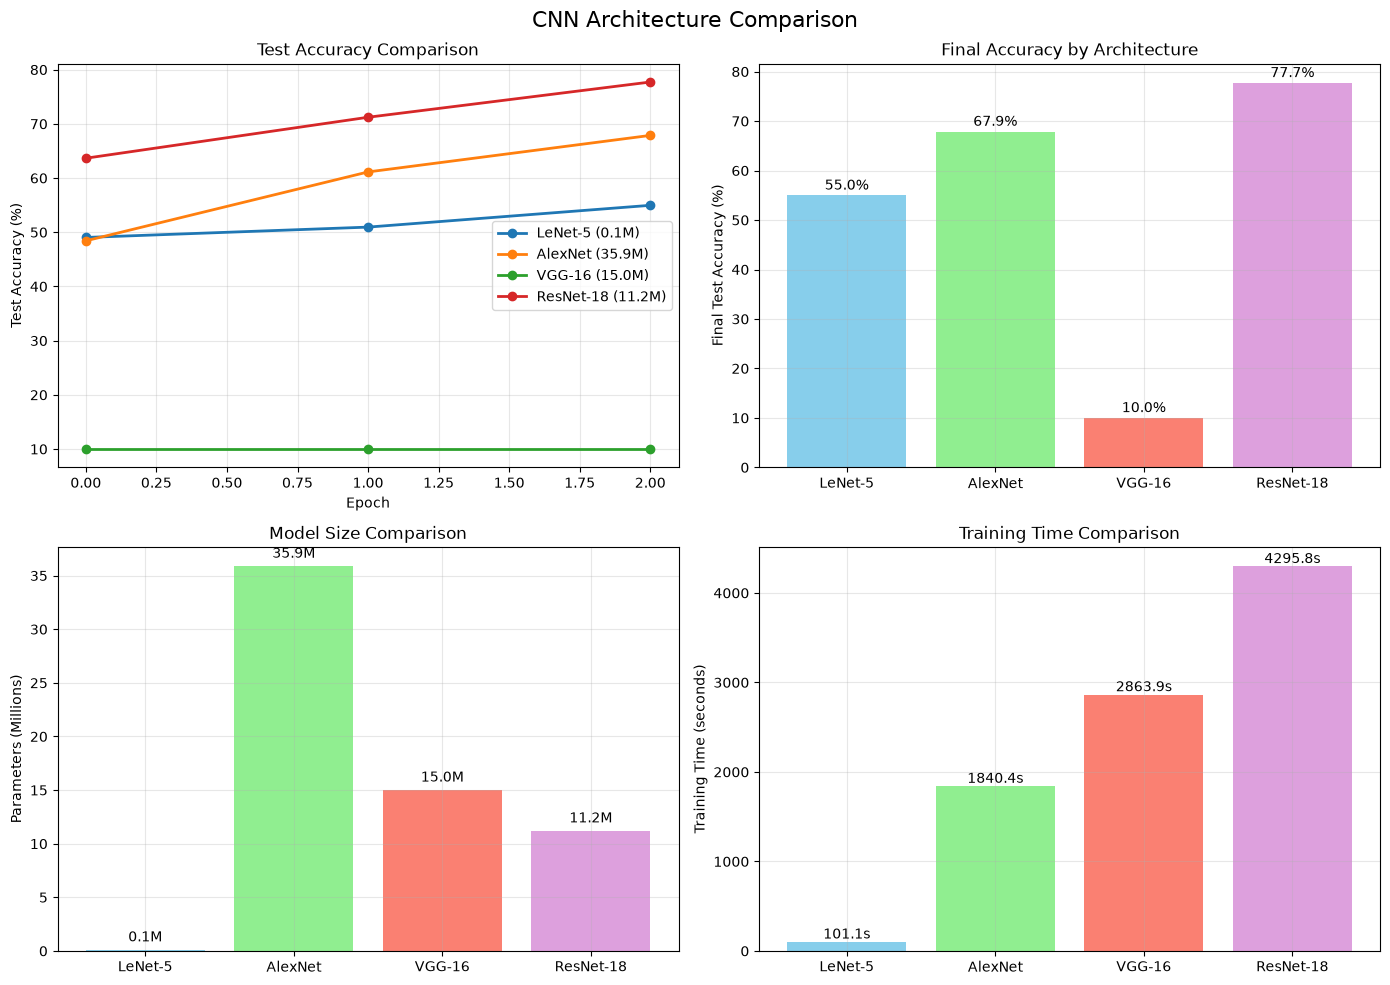

In [17]:
print("\n" + "="*60)
print("VISUALIZING ARCHITECTURE COMPARISON")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Test accuracy comparison
ax = axes[0, 0]
for name, data in results.items():
    ax.plot(data['test_accs'], label=f"{name} ({data['params']/1e6:.1f}M)", 
            linewidth=2, marker='o')
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Test Accuracy Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Parameters vs Accuracy
ax = axes[0, 1]
names = list(results.keys())
params = [results[n]['params']/1e6 for n in names]
final_accs = [results[n]['test_accs'][-1] for n in names]

bars = ax.bar(names, final_accs, color=['skyblue', 'lightgreen', 'salmon', 'plum'])
ax.set_ylabel('Final Test Accuracy (%)')
ax.set_title('Final Accuracy by Architecture')
for bar, acc in zip(bars, final_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.1f}%', ha='center', va='bottom')
ax.grid(True, alpha=0.3)

# Plot 3: Parameters comparison
ax = axes[1, 0]
bars = ax.bar(names, params, color=['skyblue', 'lightgreen', 'salmon', 'plum'])
ax.set_ylabel('Parameters (Millions)')
ax.set_title('Model Size Comparison')
for bar, p in zip(bars, params):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{p:.1f}M', ha='center', va='bottom')
ax.grid(True, alpha=0.3)

# Plot 4: Training time comparison
ax = axes[1, 1]
times = [results[n]['train_time'] for n in names]
bars = ax.bar(names, times, color=['skyblue', 'lightgreen', 'salmon', 'plum'])
ax.set_ylabel('Training Time (seconds)')
ax.set_title('Training Time Comparison')
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{t:.1f}s', ha='center', va='bottom')
ax.grid(True, alpha=0.3)

plt.suptitle('CNN Architecture Comparison', fontsize=16)
plt.tight_layout()
plt.show()

### CNN Architectures Comparison

| Architecture | Year | Parameters | Key Innovation |
|---|---|---|---|
| **LeNet-5** | 1998 | 60K | Conv + Pooling |
| **AlexNet** | 2012 | 60M | ReLU + Dropout |
| **VGG-16** | 2014 | 138M | Deep + Small (3×3) filters |
| **ResNet-18** | 2015 | 11M | Skip Connections (Residual) |

### CNN Architectures: Key Insights

#### 1. LeNet-5 (1998)
- ✅ **Pioneer:** First successful CNN
- ✅ **Simple:** 2 conv layers
- ❌ **Limited:** Small capacity

#### 2. AlexNet (2012)
- ✅ **Breakthrough:** Won ImageNet
- ✅ **ReLU:** Solved vanishing gradient
- ✅ **Dropout:** Prevented overfitting
- ✅ **Data Augmentation:** More training data

#### 3. VGG-16 (2014)
- ✅ **Deep:** 16 layers
- ✅ **Simple:** Uniform architecture (all 3×3)
- ✅ **Effective:** Strong performance
- ❌ **Large:** 138M parameters
- ❌ **Slow:** Many computations

#### 4. ResNet-18 (2015)
- ✅ **Skip Connections:** Solved vanishing gradient
- ✅ **Deep:** Can train 100+ layers
- ✅ **Efficient:** Only 11M parameters
- ✅ **Better:** Higher accuracy than VGG
- ✅ **Standard:** Most modern networks use residual connections

#### Tips

- Deeper networks don't always mean better (need skip connections!)
- Small filters (3×3) work well
- ReLU is the standard activation
- Dropout prevents overfitting
- Skip connections enable very deep networks
- More parameters ≠ better accuracy


#### Best Practice

- Start with **ResNet-18** (good balance)
- Use **pre-trained models** (transfer learning)
- **Data augmentation** is crucial
- **Batch Normalization** helps training    